In [25]:
import control as ct
from control.matlab import *
import numpy as np

In [2]:
G0 = ct.tf(20, [1000, 1], name = "G0"); [delay_num, delay_den] = ct.pade(100, 3); Pade_delay = ct.tf(delay_num, delay_den); G = ct.series(G0, Pade_delay, name="G")

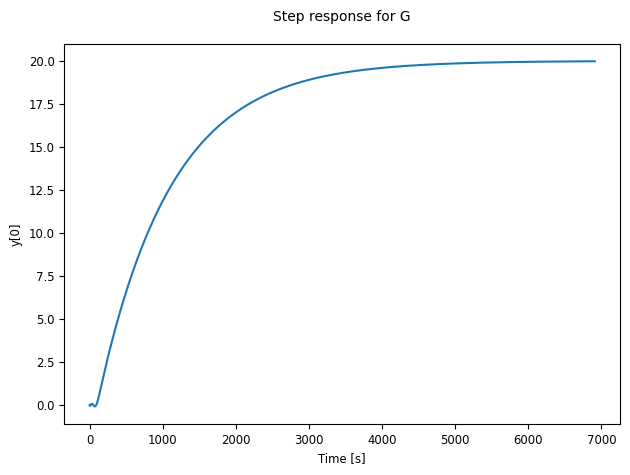

In [3]:
ct.step_response(G).plot()

In [28]:
K = ct.tf([0.25*800, 0.25], [800, 0], name="K, Ti=800s")

In [5]:
print(K)

<TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


200 s + 0.25
------------
   800 s



In [7]:
loop = ct.series(K,G, name="loop TI=800sec"); print(loop)

<TransferFunction>: loop TI=800sec
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


    -4000 s^4 + 475 s^3 - 23.4 s^2 + 0.45 s + 0.0006
---------------------------------------------------------
8e+05 s^5 + 9.68e+04 s^4 + 4896 s^3 + 100.8 s^2 + 0.096 s



In [8]:
clsd = ct.feedback (loop, 1, sign = -1, name="clsd TI=800s")

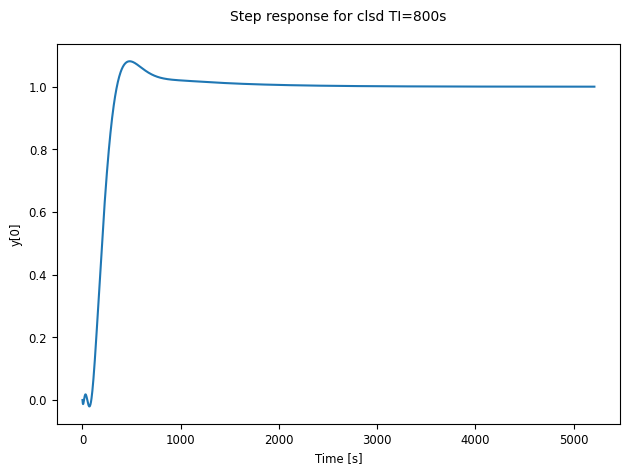

In [9]:
ct.step_response(clsd).plot()

In [10]:
K2 = ct.tf([0.4*200, 0.4], [200, 0]); Kd1 = ct.tf([30, 1], [3, 1]); K3=ct.series (K2, Kd1, name="K3 PID Td=30s"); Kd2 = ct.tf([60, 1], [6, 1]);
K4=ct.series (K2, Kd2, name="K4 PID Td=60s"); Kd3 = ct.tf([90, 1], [9, 1]); K5=ct.series (K2, Kd3, name="K5 PID Td=60s");
                                                                                    

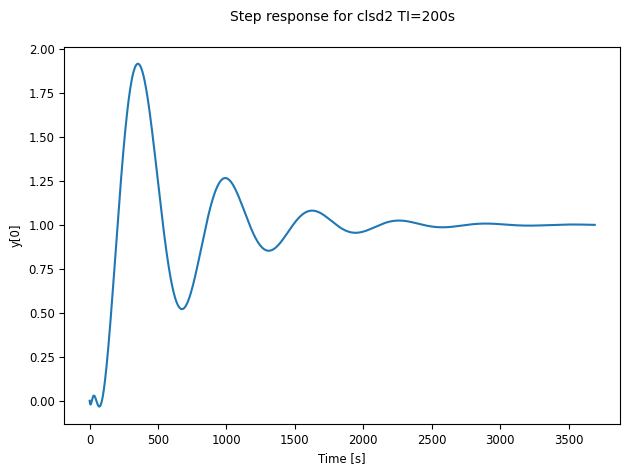

In [11]:
loop2 = ct.series(K2, G, name="loop2 TI=200s"); clsd2 = ct.feedback(loop2, 1, sign=-1, name="clsd2 TI=200s"); ct.step_response(clsd2).plot()

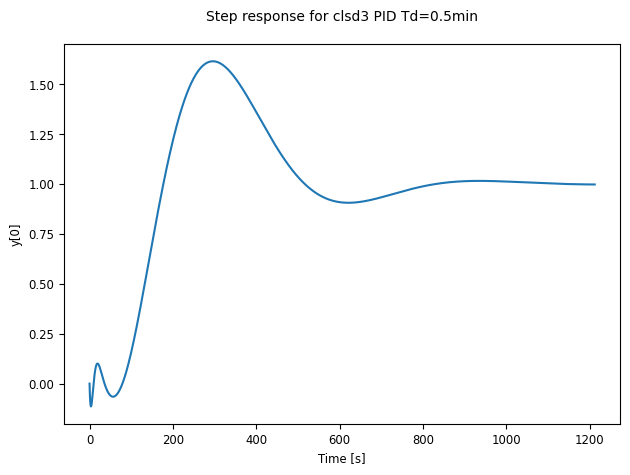

In [12]:
loop3 = ct.series(K3, G, name="loop3 PID Td=0.5min"); clsd3 = ct.feedback(loop3, 1, sign=-1, name="clsd3 PID Td=0.5min"); ct.step_response(clsd3).plot()

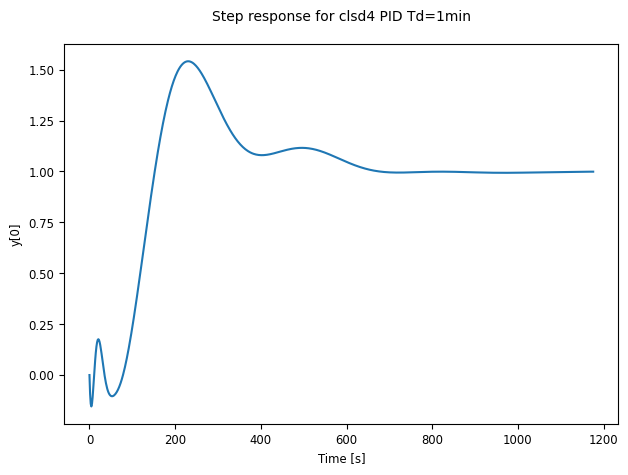

In [13]:
loop4 = ct.series(K4, G, name="loop4 PID Td=1min"); clsd4 = ct.feedback(loop4, 1, sign=-1, name="clsd4 PID Td=1min"); ct.step_response(clsd4).plot()

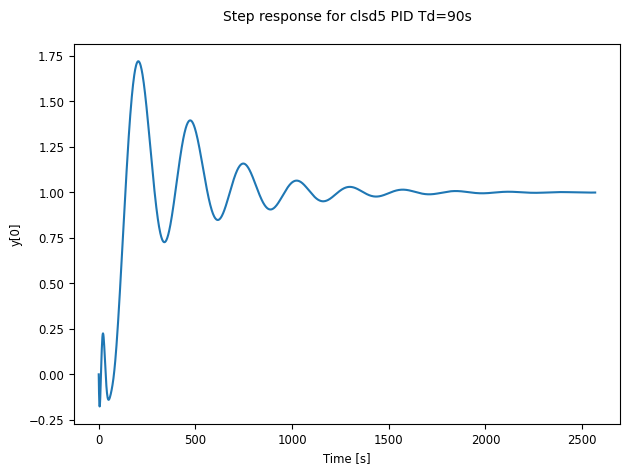

In [14]:
loop5 = ct.series(K5, G, name="loop5 PID Td=90s"); clsd5 = ct.feedback(loop5, 1, sign=-1, name="clsd5 PID Td=90s"); ct.step_response(clsd5).plot()

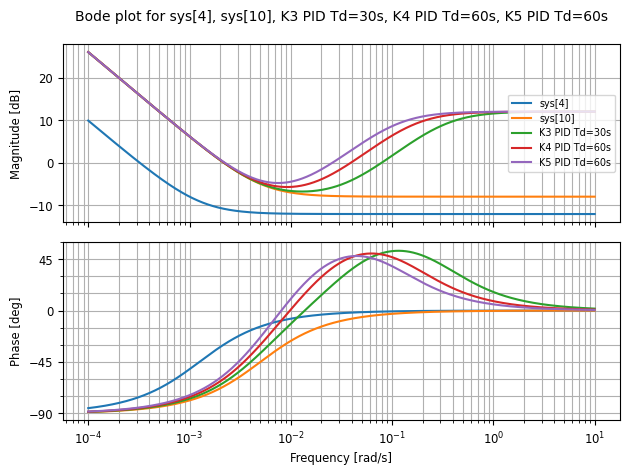

In [15]:
ct.bode([K, K2, K3, K4, K5])

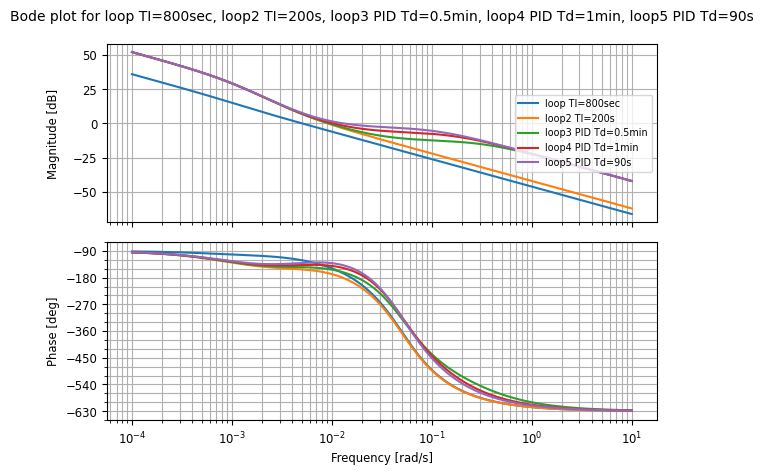

In [13]:
ct.bode([ loop, loop2, loop3, loop4, loop5])

In [16]:
bd0 = ct.bandwidth(G); bd1 = bandwidth(clsd); bd2 = bandwidth(clsd2);  bd3 = bandwidth(clsd3); bd4 = bandwidth(clsd4); bd5=bandwidth(clsd5); print("bd0=", bd0, "bd1=", bd1, "bd2=", bd2, "bd3=", bd3, "bd4=", bd4, "bd5=", bd5)

bd0= 0.000997628345495443 bd1= 0.011383161821016678 bd2= 0.01839706319242974 bd3= 0.02285152152149531 bd4= 0.03217308826006692 bd5= 0.03700935494611278


In [54]:
margin(loop)


(3.106406686037892,
 58.349437632810066,
 0.015550014501913146,
 0.00505272788973786)

In [55]:
margin(loop2)

(1.4889437987882264,
 15.427299564456547,
 0.01275493011131702,
 0.009078223582734196)

In [56]:
margin(loop3)

(1.9094215058821853,
 28.427620619280134,
 0.01795705332658584,
 0.0093632298958237)

In [57]:
margin(loop4)

(1.629092591375522,
 38.63376214266219,
 0.02181456644038322,
 0.010394105098284421)

In [72]:
margin(loop5)

(1.252579568585143,
 41.34516631674717,
 0.02323328804072834,
 0.013116019449036386)

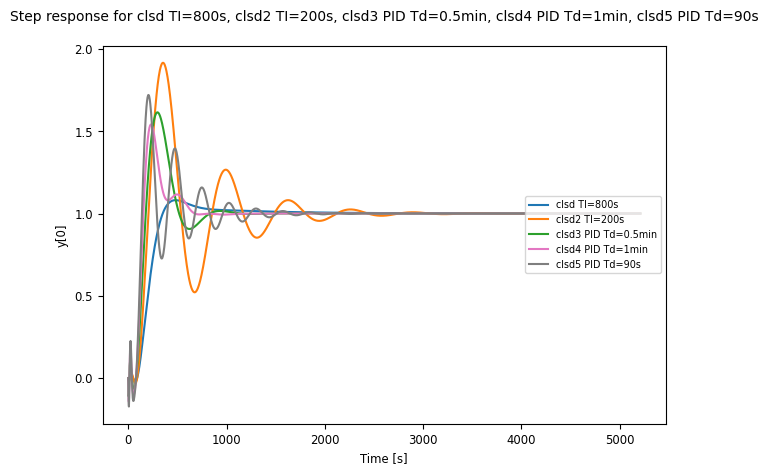

In [17]:
ct.step_response([clsd, clsd2, clsd3, clsd4, clsd5]).plot()

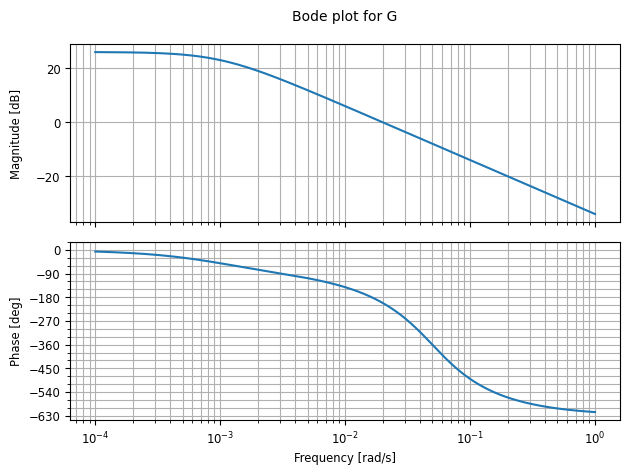

In [3]:
ct.bode(G)

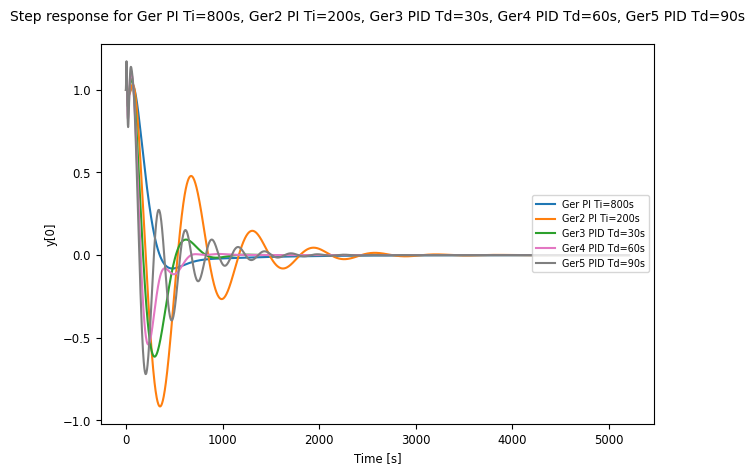

In [45]:
Gd = ct.tf([10], [1000, 1]);  Gr = ct.tf(3, [150, 1]);
Ger = ct.feedback(1, loop, sign=-1, name="Ger PI Ti=800s");
Ger2 = ct.feedback(1, loop2, sign=-1, name="Ger2 PI Ti=200s");
Ger3 = ct.feedback(1, loop3, sign=-1, name="Ger3 PID Td=30s");
Ger4 = ct.feedback(1, loop4, sign=-1, name="Ger4 PID Td=60s");
Ger5 = ct.feedback(1, loop5, sign=-1, name="Ger5 PID Td=90s");

#Gud = ct.series(ct.series(Gd, K), Ger, name="Gud PI Ti=800s");
#Gud2 = ct.series(ct.series(Gd, K2), Ger, name="Gud2 PI Ti=200s");
#Gud3 = ct.series(Gd*K3, Ger, name="Gud3 PID Td=30s");
#Gud4 = ct.series(Gd*K4, Ger, name="Gud4 PID Td=60s");
#Gud5 = ct.series(Gd*K5, Ger, name="Gud5 PID Td=90s");

Ged = ct.series(Gd, Ger, name="Ged PI Ti=800s");
Ged2 = ct.series(Gd, Ger2, name="Ged PI Td=200s");
Ged3 = ct.series(Gd, Ger3, name="Ged PID Td=30s");
Ged4 = ct.series(Gd, Ger4, name="Ged PID Td=60s");
Ged5 = ct.series(Gd, Ger5, name="Ged PID Td=90s");

Gud = ct.series(Ged, K, name="Gud PI Ti=800s");
Gud2 = ct.series(Ged2, K2, name="Gud2 PI Ti=200s");
Gud3 = ct.series(Ged3, K3, name="Gud3 PID Td=30s");
Gud4 = ct.series(Ged4, K4, name="Gud4 PID Td=60s");
Gud5 = ct.series(Ged5, K5, name="Gud5 PID Td=90s");

Gyr = ct.series(clsd, Gr, name="Gyr, PI Ti=800s");
Gyr2 = ct.series(clsd2, Gr, name="Gyr2, PI Ti=200s");
Gyr3 = ct.series(clsd3, Gr, name="Gyr3, PID Td=30s");
Gyr4 = ct.series(clsd4, Gr, name="Gyr4, PID Td=60s");
Gyr5 = ct.series(clsd5, Gr, name="Gyr5, PID Td=90s");

ct.step_response([Ger, Ger2, Ger3, Ger4, Ger5]).plot();



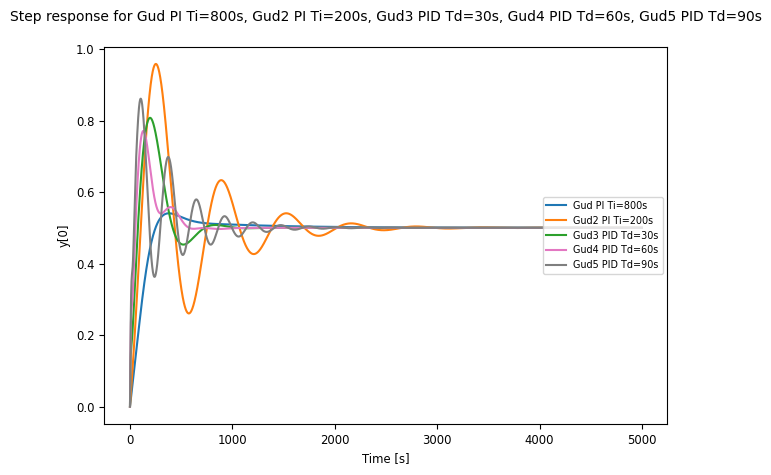

In [40]:
timepts = np.linspace(0, 5000, 5000)
ct.step_response([Gud, Gud2, Gud3, Gud4, Gud5], timepts).plot();


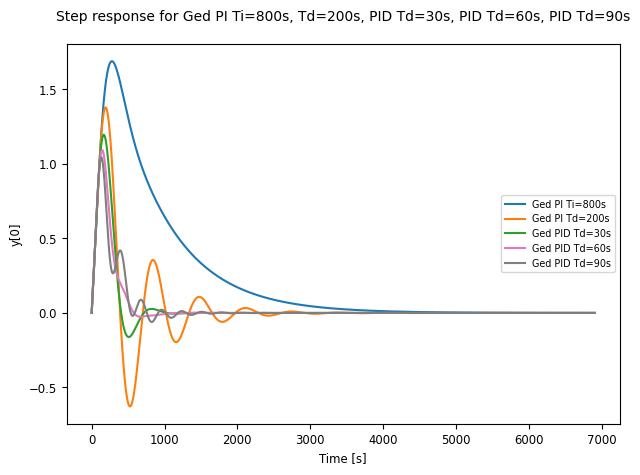

In [36]:
ct.step_response([Ged, Ged2, Ged3, Ged4, Ged5]).plot();

In [41]:
print("Ged PI Ti=800s, bandwidth=", bandwidth(Ged), "Ged2 PI=200s, bandwidth=", bandwidth(Ged2), "Ged3 PID Td=30s", bandwidth(Ged3), "Ged4 PID Td=60s, bandwidth=", bandwidth(Ged4), "Ged5 PID Td=90s, bandwidth=", bandwidth(Ged5))

Ged PI Ti=800s, bandwidth= inf Ged2 PI=200s, bandwidth= inf Ged3 PID Td=30s inf Ged4 PID Td=60s, bandwidth= inf Ged5 PID Td=90s, bandwidth= inf


In [43]:
print("Ged PI Ti=800s, margin:", margin(Ged), "Ged2 PI=200s, margin:", margin(Ged2), "Ged3 PID Td=30s margin:", margin(Ged3), "Ged4 PID Td=60s, margin:", margin(Ged4), "Ged5 PID Td=90s, margin=", margin(Ged5))

Ged PI Ti=800s, margin: (inf, 95.46415766445944, nan, 0.014971728684110567) Ged2 PI=200s, margin: (inf, 75.47492546102012, nan, 0.017235494194082348) Ged3 PID Td=30s margin: (inf, 87.3861294293826, nan, 0.01942255825090625) Ged4 PID Td=60s, margin: (inf, 80.72287945646627, nan, 0.02369450907297935) Ged5 PID Td=90s, margin= (inf, 49.73467494785669, nan, 0.027049701985403272)


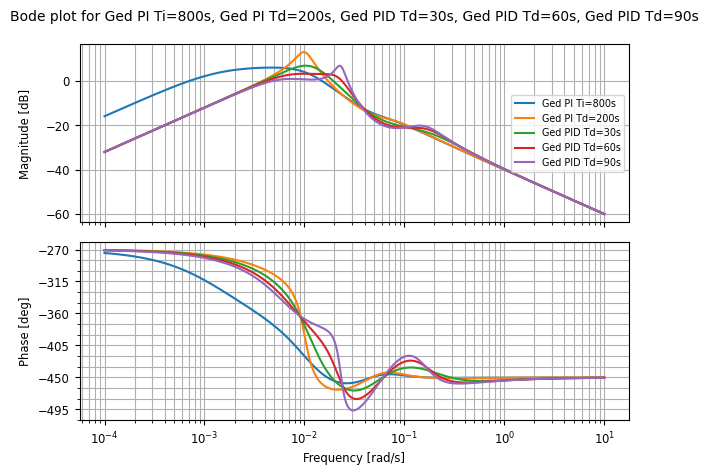

In [44]:
ct.bode([Ged, Ged2, Ged3, Ged4, Ged5]);

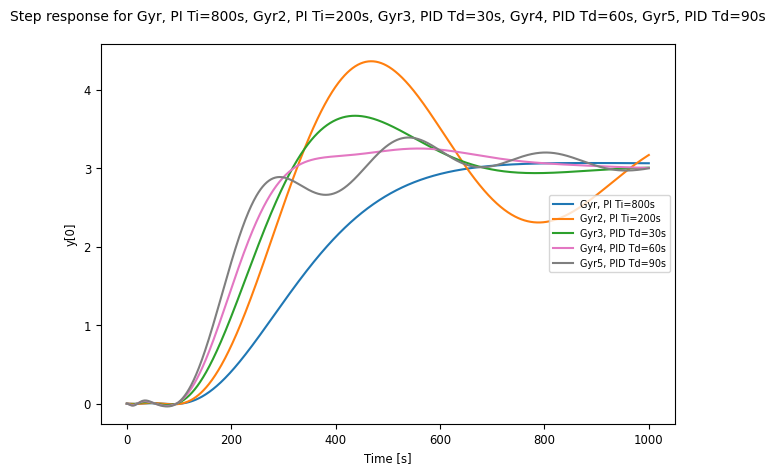

In [48]:
timepts = np.linspace(0, 1000, 1000)
ct.step_response([Gyr, Gyr2, Gyr3, Gyr4, Gyr5], timepts).plot();

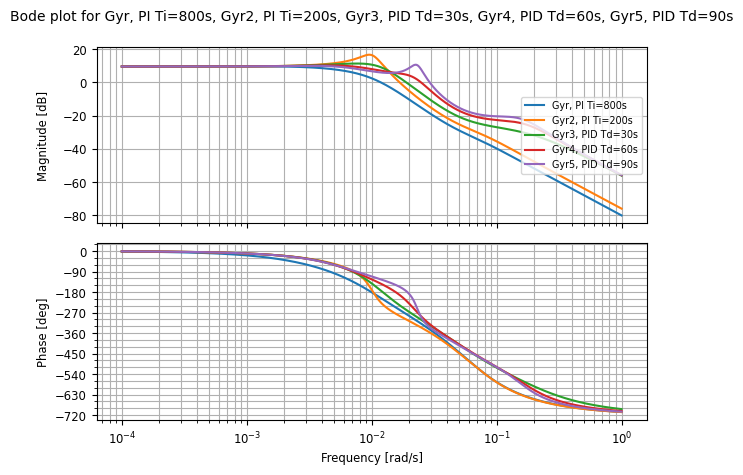

In [49]:
ct.bode([Gyr, Gyr2, Gyr3, Gyr4, Gyr5]);